In [1]:
# Import the required libraries.
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from shapely.geometry import shape

In [2]:
# Load the original Water Flow Routes dataset.
flow_raw = pd.read_csv("water-flow-routes-over-land-urban-forest.csv")

In [3]:
# Create working copies so the original datasets remain unchanged.
flow = flow_raw.copy()

In [4]:
# Define a function to check size, columns, data types, missing values and duplicate rows.
def check_dataframe(df, name):
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # Preview the first five rows.
    display(df.head())

    # Check the data type of each column.
    print("\nData types:")
    display(df.dtypes.to_frame("data_type"))

    # Check missing values in each column.
    print("\nMissing values:")
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": (df.isna().mean() * 100).round(2)
    })

    display(missing.sort_values("missing_percentage", ascending=False))

    # Count identical rows.
    print("\nDuplicate rows:", df.duplicated().sum())

In [5]:
# Check the water-flow-route dataset.
check_dataframe(flow, "Water Flow Routes")

Shape: 7,701 rows × 7 columns


,Geo Point,Geo Shape,grid_code,source,to_node,arcid,from_node
0,"-37.80099436679903, 144.9534200100625","{""coordinates"": [[[144.95386264049685, -37.800...",3,2008 DEM to stream order using ESRI Spatial An...,1855,1999,1799
1,"-37.800568902802134, 144.91665018543864","{""coordinates"": [[[144.91625498613098, -37.800...",1,2008 DEM to stream order using ESRI Spatial An...,1830,2022,1875
2,"-37.802276643873995, 144.93296026306035","{""coordinates"": [[[144.9329545870473, -37.8022...",2,2008 DEM to stream order using ESRI Spatial An...,1987,2139,1986
3,"-37.80237643867766, 144.9740144185731","{""coordinates"": [[[144.9741364101668, -37.8014...",1,2008 DEM to stream order using ESRI Spatial An...,2032,2198,1843
4,"-37.8027555784182, 144.94459804842043","{""coordinates"": [[[144.94463313406013, -37.802...",1,2008 DEM to stream order using ESRI Spatial An...,2040,2204,2008



Data types:


,data_type
Geo Point,object
Geo Shape,object
grid_code,int64
source,object
to_node,int64
arcid,int64
from_node,int64



Missing values:


,missing_count,missing_percentage
Geo Point,0,0.0
Geo Shape,0,0.0
grid_code,0,0.0
source,0,0.0
to_node,0,0.0
arcid,0,0.0
from_node,0,0.0



Duplicate rows: 0


In [6]:
# Define a function to standardise column names.
def standardise_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )

    return df

In [7]:
# Standardise the flow-route column names.
flow = standardise_column_names(flow)

In [8]:
# Display the standardised column names.
print(flow.columns.tolist())

['geo_point', 'geo_shape', 'grid_code', 'source', 'to_node', 'arcid', 'from_node']


In [9]:
# Check whether arcid is a valid unique identifier.
flow_identifier_check = pd.Series({
    "total_rows": len(flow),
    "missing_arcid": flow["arcid"].isna().sum(),
    "duplicated_arcid": (
        flow["arcid"]
        .dropna()
        .duplicated()
        .sum()
    )
})

display(flow_identifier_check)

total_rows          7701
missing_arcid          0
duplicated_arcid       0
dtype: int64

In [10]:
# Check stream-order and source values.
print("GRID_CODE values:")
display(
    flow["grid_code"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nSource values:")
display(
    flow["source"]
    .value_counts(dropna=False)
)

GRID_CODE values:


grid_code
1    3881
2    2206
3    1245
4     359
5      10
Name: count, dtype: int64


Source values:


source
2008 DEM to stream order using ESRI Spatial Analy*    7701
Name: count, dtype: int64

In [11]:
# Convert identifier and stream-order fields to nullable integers.
flow_integer_columns = [
    "grid_code",
    "to_node",
    "arcid",
    "from_node"
]

for column in flow_integer_columns:
    flow[column] = (
        pd.to_numeric(
            flow[column],
            errors="coerce"
        )
        .astype("Int64")
    )

# Check missing values after conversion.
display(
    flow[flow_integer_columns]
    .isna()
    .sum()
)

grid_code    0
to_node      0
arcid        0
from_node    0
dtype: int64

In [12]:
# Convert GeoJSON values to Shapely geometry.
def parse_geojson_geometry(value):
    if pd.isna(value):
        return None

    try:
        geojson_object = (
            json.loads(value)
            if isinstance(value, str)
            else value
        )

        return shape(geojson_object)

    except (
        json.JSONDecodeError,
        TypeError,
        ValueError,
        KeyError
    ):
        return None


# Parse the flow-route GeoJSON geometry.
flow["geometry"] = flow["geo_shape"].apply(
    parse_geojson_geometry
)

# Convert the DataFrame to a GeoDataFrame.
flow_gdf = gpd.GeoDataFrame(
    flow.copy(),
    geometry="geometry",
    crs="EPSG:4326"
)

# Identify geometry-quality issues.
missing_geometry = flow_gdf.geometry.isna()

empty_geometry = (
    flow_gdf.geometry.notna()
    & flow_gdf.geometry.is_empty
)

invalid_geometry = (
    flow_gdf.geometry.notna()
    & ~flow_gdf.geometry.is_empty
    & ~flow_gdf.geometry.is_valid
)

parsing_failure = (
    flow["geo_shape"].notna()
    & flow["geometry"].isna()
)

# Summarise geometry quality.
flow_geometry_quality = pd.Series({
    "total_records": len(flow_gdf),
    "missing_geometry": missing_geometry.sum(),
    "parsing_failures": parsing_failure.sum(),
    "empty_geometry": empty_geometry.sum(),
    "invalid_geometry": invalid_geometry.sum()
})

print("Water Flow Routes geometry types:")

display(
    flow_gdf.geometry
    .apply(
        lambda geometry: (
            geometry.geom_type
            if geometry is not None
            else "Missing"
        )
    )
    .value_counts()
)

display(flow_geometry_quality)

Water Flow Routes geometry types:


geometry
MultiLineString    7701
Name: count, dtype: int64

total_records       7701
missing_geometry       0
parsing_failures       0
empty_geometry         0
invalid_geometry       0
dtype: int64

In [13]:
# Create the final cleaned Water Flow Routes dataset.
flow_clean = flow_gdf.copy()

# Clean the flow-route source description.
flow_clean["source"] = (
    flow_clean["source"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

# Project the geometry for length calculations in metres.
PROJECTED_CRS = "EPSG:7855"
flow_projected = flow_clean.to_crs(PROJECTED_CRS)

In [14]:
# Validate the cleaned source description.
assert flow_clean["source"].notna().all()

assert flow_clean["source"].eq(
    flow_clean["source"].str.strip()
).all()

print("The cleaned source field passed validation.")

The cleaned source field passed validation.


In [15]:
# Data Wrangling and Derived Variables
# Calculate route lengths in metres using the projected geometry.
flow_projected["route_length_m"] = (
    flow_projected.geometry.length
)

# Add the calculated length to the final cleaned dataset.
flow_clean["route_length_m"] = (
    flow_projected["route_length_m"]
)

# Identify missing or non-positive route lengths.
invalid_route_lengths = (
    flow_projected["route_length_m"].isna() |
    (flow_projected["route_length_m"] <= 0)
)

# Display the overall route-length distribution.
display(
    flow_projected["route_length_m"]
    .describe()
    .round(2)
)

print(
    "Missing or non-positive route lengths:",
    invalid_route_lengths.sum()
)

# Summarise route lengths by Strahler stream order.
flow_stream_order_summary = (
    flow_projected
    .groupby("grid_code", dropna=False)
    .agg(
        route_segment_count=("arcid", "size"),
        total_route_length_m=("route_length_m", "sum"),
        average_route_length_m=("route_length_m", "mean"),
        median_route_length_m=("route_length_m", "median"),
        maximum_route_length_m=("route_length_m", "max")
    )
    .reset_index()
    .rename(
        columns={
            "grid_code": "strahler_stream_order"
        }
    )
)

display(flow_stream_order_summary.round(2))

count    7701.00
mean       53.13
std        84.12
min         1.00
25%         1.00
50%        10.41
75%        78.30
max      1079.57
Name: route_length_m, dtype: float64

Missing or non-positive route lengths: 0


,strahler_stream_order,route_segment_count,total_route_length_m,average_route_length_m,median_route_length_m,maximum_route_length_m
0,1,3881,231491.83,59.65,18.54,1079.57
1,2,2206,107929.83,48.93,9.32,744.61
2,3,1245,49275.66,39.58,2.24,759.43
3,4,359,19266.64,53.67,20.71,485.51
4,5,10,1211.23,121.12,72.37,387.05


In [16]:
# Validate the final Water Flow Routes dataset.
assert len(flow_clean) == len(flow_raw)
assert flow_clean["arcid"].is_unique
assert flow_clean["arcid"].notna().all()
assert flow_clean.geometry.notna().all()
assert flow_clean.geometry.is_valid.all()
assert flow_clean["route_length_m"].notna().all()
assert (flow_clean["route_length_m"] > 0).all()

assert (
    flow_stream_order_summary["route_segment_count"].sum()
    == len(flow_clean)
)

print("The final Water Flow Routes dataset passed validation.")

The final Water Flow Routes dataset passed validation.


In [17]:
# Create separate folders for Water Flow Routes outputs.
OUTPUT_DIR = Path("outputs/water_flow_routes")
CLEANED_DIR = OUTPUT_DIR / "cleaned_data"
FIGURE_DIR = OUTPUT_DIR / "figures"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Save, display and close a figure.
def save_and_show_figure(filename):
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

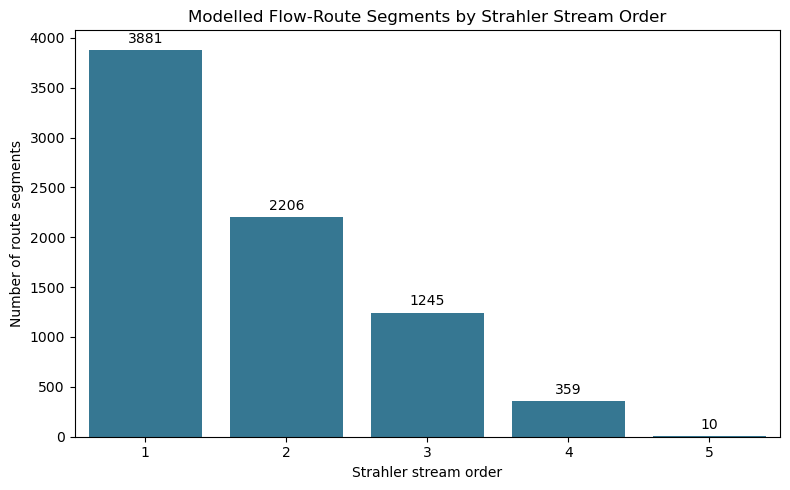

In [18]:
# Visualise route-segment counts by Strahler stream order.
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=flow_stream_order_summary,
    x="strahler_stream_order",
    y="route_segment_count",
    color="#277DA1",
    errorbar=None
)

ax.set_title(
    "Modelled Flow-Route Segments by Strahler Stream Order"
)
ax.set_xlabel("Strahler stream order")
ax.set_ylabel("Number of route segments")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

save_and_show_figure(
    "flow_routes_by_strahler_order.png"
)

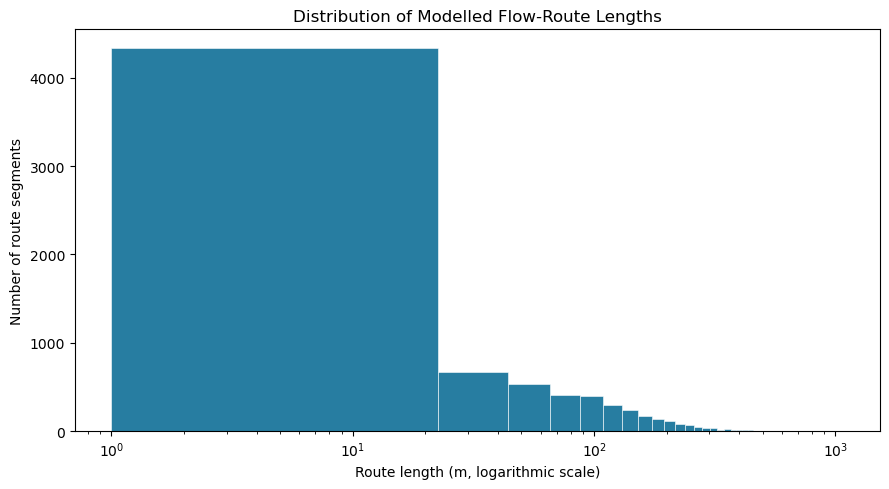

In [19]:
# Visualise positive route lengths on a logarithmic scale.
positive_route_lengths = flow_projected.loc[
    flow_projected["route_length_m"] > 0,
    "route_length_m"
]

plt.figure(figsize=(9, 5))

plt.hist(
    positive_route_lengths,
    bins=50,
    color="#277DA1",
    edgecolor="white",
    linewidth=0.4
)

plt.xscale("log")
plt.title("Distribution of Modelled Flow-Route Lengths")
plt.xlabel("Route length (m, logarithmic scale)")
plt.ylabel("Number of route segments")

save_and_show_figure(
    "flow_route_length_distribution.png"
)

In [20]:
# Export the cleaned Water Flow Routes dataset.
flow_export = (
    flow_clean
    .drop(columns="geometry")
    .copy()
)

flow_export.to_csv(
    CLEANED_DIR / "water_flow_routes_cleaned.csv",
    index=False
)

# Export the Strahler stream-order summary.
flow_stream_order_summary.to_csv(
    CLEANED_DIR / "flow_stream_order_summary.csv",
    index=False
)

In [22]:
# Confirm that the expected Water Flow Routes files were created.
expected_output_files = [
    "water_flow_routes_cleaned.csv",
    "flow_stream_order_summary.csv"
]

for filename in expected_output_files:
    output_path = CLEANED_DIR / filename

    assert output_path.exists()

    print(f"Exported: {output_path}")

Exported: outputs/water_flow_routes/cleaned_data/water_flow_routes_cleaned.csv
Exported: outputs/water_flow_routes/cleaned_data/flow_stream_order_summary.csv


## Key Findings

- The Water Flow Routes dataset contained 7,701 route segments and no exact duplicate rows.
- The `arcid` field contained no missing or duplicated values and was retained as the unique route-segment identifier.
- All 7,701 GeoJSON geometries were successfully parsed as MultiLineString geometries. No missing, empty or invalid geometries were identified.
- The `grid_code` field contained five Strahler stream orders. Order 1 contained 3,881 route segments, followed by 2,206 order-2 segments, 1,245 order-3 segments, 359 order-4 segments and 10 order-5 segments.
- The median modelled route-segment length was 10.41 metres and the mean was 53.13 metres. The longest segment was 1,079.57 metres.
- No missing or non-positive route lengths were identified after projection to EPSG:7855.

## Limitations

- The routes were derived from a 2008 digital elevation model using the ESRI Spatial Analyst stream-order tool with Strahler ordering.
- The dataset represents modelled surface-water flow routes rather than observed or real-time water movement.
- The source documentation states that part of Kensington is excluded because it became part of the City of Melbourne after the data was processed.
- Route length describes the length of each mapped segment. It does not measure water volume, flow speed, drainage capacity or flood depth.
- The dataset does not include rainfall intensity, underground drainpipes, stormwater pits, blocked drains or current drainage conditions.